## Here we compare the our analytic found formulas with their numerical values 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from spike_lib import TwoSpikes

### 1rst Part: eigenvalues and eigenvectors of our signal

For our signals $x_1$ and $x_2$, we have defined the observation $Y = \alpha  Y_1 + \sqrt{1-\alpha^2}  Y_2$ with $Y_i \, = \, \lambda _i  x_i  x_i^T +  Z_i$.

Here we consider our observation without noise and analyse $P := a x_1 x_1 ^T + b x_2 x_2^T$ where $a = \alpha \lambda_1$ and $b =  \sqrt{1-\alpha^2} \lambda_2$.

In this part we will compare the analytical and numerical solutions of the eigenvectors and eigenvalues of $P$.

In [ ]:

alpha=np.sqrt(0.5)

N = 1000
rho = 0.2
lam1 = 2
lam2 = 3 
M = 2
LAM1 = np.zeros(M)
LAM2 = np.zeros(M)
m1 = np.zeros(M)
m2 = np.zeros(M)

for m in range(M):

    S = TwoSpikes(N, rho, lam1, lam2)
    
    eigenvalues, eigenvectors =  S.eigen_P()

    LAM1[m] = eigenvalues[0]
    LAM2[m] = eigenvalues[1]
    v1_t = eigenvectors[:, 0]
    v2_t = eigenvectors[:, 1]

    v1, v2 = S.theory_vp()

    m1[m] = abs(np.dot(v1, v1_t)/(np.linalg.norm(v1)*np.linalg.norm(v1_t)))
    m2[m] = abs(np.dot(v2, v2_t)/(np.linalg.norm(v2)*np.linalg.norm(v2_t)))

l1, l2 = S.theory_eig()
print("Eigenvalues:", f"{LAM1.mean():.2f} +- {np.std(LAM1):.2f}", f"{LAM2.mean():.2f} +- {np.std(LAM2):.2f}")  # Print the two largest eigenvalues
print("Theoretical Eigenvalues:", f"{l1:.2f} ", f"{l2:.2f} ")  # Print the theoretical eigenvalues
print("Eigenvector overlaps:", f"{m1.mean():.2f} +- {np.std(m1):.2f}", f"{m2.mean():.2f} +- {np.std(m2):.2f}")  # Print the overlaps of the eigenvectors with the theoretical ones

Eigenvalues: 1.43 +- 0.00 0.13 +- 0.00
Theoretical Eigenvalues: 2.26  -0.71 
Eigenvector overlaps: 0.99 +- 0.00 0.52 +- 0.00


In [ ]:

def theory_eig(a, b, rho):
        """Compute the theoretical eigenvalues of the matrix P."""
        lam1 = (a+b)/2 + np.sqrt((a-b)**2/4 + a*b*rho**2)
        lam2 = (a+b)/2 - np.sqrt((a-b)**2/4 + a*b*rho**2)
        # lam = (a+b)/2 +- sqrt((a-b)^2 /4 + ab rho^2)
        return lam1, lam2



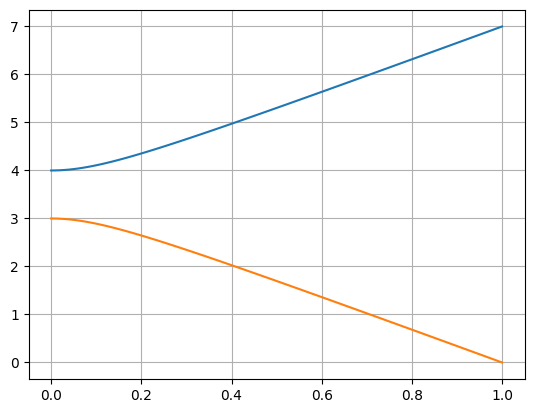

In [11]:
#Plot theory eigenval vs rho
a = 4
b = 3

RHO = np.linspace(0, 1, 100)
lam1, lam2 = theory_eig(a, b, RHO)
plt.plot(RHO, lam1, label='lam1')
plt.plot(RHO, lam2, label='lam2') 

plt.grid()  
plt.show()

